Q3 Function to equalize the histogram of an image and apply this function to the runway image

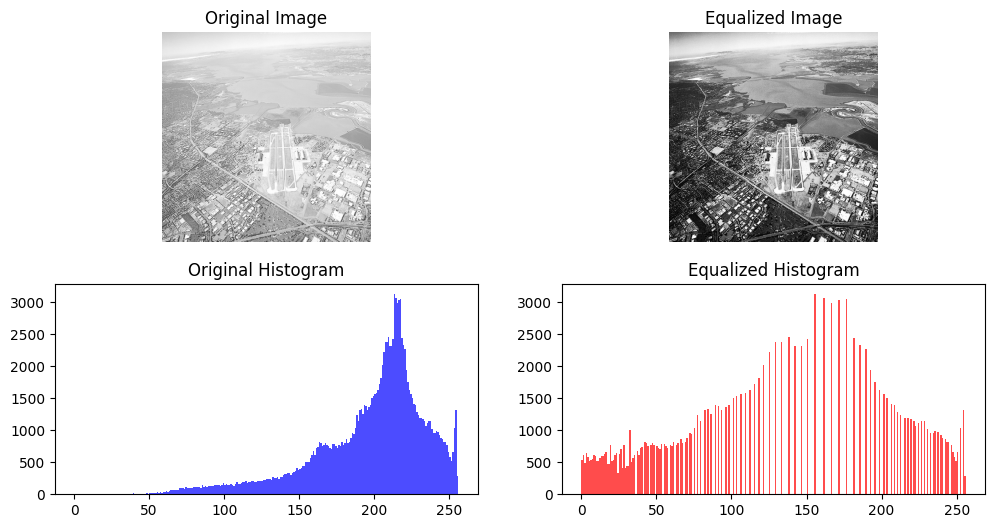

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def my_hist_equalization(img):
    """
    Perform histogram equalization manually on a grayscale image.
    """
    # Flatten the image to 1D
    hist, bins = np.histogram(img.flatten(), 256, [0,256])
    
    # Compute cumulative distribution function (CDF)
    cdf = hist.cumsum()
    
    # Normalize CDF to [0,255]
    cdf_normalized = cdf * 255 / cdf[-1]
    
    # Use linear interpolation to map pixel values
    img_equalized = np.interp(img.flatten(), bins[:-1], cdf_normalized)
    
    # Reshape back to original image shape
    return img_equalized.reshape(img.shape).astype(np.uint8)

#load the image in grayscale mode
f = cv.imread('/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 01/runway.png', cv.IMREAD_REDUCED_GRAYSCALE_2)
assert f is not None

# Apply custom histogram equalization
img_eq = my_hist_equalization(f)

# Display results
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.title("Original Image")
plt.imshow(f, cmap='gray')
plt.axis("off")

plt.subplot(2,2,2)
plt.title("Equalized Image")
plt.imshow(img_eq, cmap='gray')
plt.axis("off")

plt.subplot(2,2,3)
plt.title("Original Histogram")
plt.hist(f.ravel(), bins=256, range=(0,256), color='blue', alpha=0.7)

plt.subplot(2,2,4)
plt.title("Equalized Histogram")
plt.hist(img_eq.ravel(), bins=256, range=(0,256), color='red', alpha=0.7)

plt.show()
